In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
btc_df = pd.read_csv('../data/raw/BTC_USDT_ohlcv_1h_10000_with_indicators.csv')
eth_df = pd.read_csv('../data/raw/ETH_USDT_ohlcv_1h_10000_with_indicators.csv')

print("BTC dataset:")
print(f"  Shape: {btc_df.shape}")
print(f"  Columns: {list(btc_df.columns)}")
print(f"  Date range: {btc_df['timestamp'].iloc[0]} → {btc_df['timestamp'].iloc[-1]}")

print("\nETH dataset:")
print(f"  Shape: {eth_df.shape}")
print(f"  Columns: {list(eth_df.columns)}")
print(f"  Date range: {eth_df['timestamp'].iloc[0]} → {eth_df['timestamp'].iloc[-1]}")

BTC dataset:
  Shape: (10000, 11)
  Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ma20', 'ma50', 'rsi', 'returns', 'vol_20']
  Date range: 2025-02-01 01:00:00 → 2026-03-24 16:00:00

ETH dataset:
  Shape: (10000, 11)
  Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ma20', 'ma50', 'rsi', 'returns', 'vol_20']
  Date range: 2025-02-01 01:00:00 → 2026-03-24 16:00:00


In [3]:
print("BTC missing values:")
print(btc_df.isnull().sum())

print("\nETH missing values:")
print(eth_df.isnull().sum())

BTC missing values:
timestamp     0
open          0
high          0
low           0
close         0
volume        0
ma20         19
ma50         49
rsi          13
returns       1
vol_20       19
dtype: int64

ETH missing values:
timestamp     0
open          0
high          0
low           0
close         0
volume        0
ma20         19
ma50         49
rsi          13
returns       1
vol_20       19
dtype: int64


In [4]:
print("BTC data types:")
print(btc_df.dtypes)

print("\nETH data types:")
print(eth_df.dtypes)

BTC data types:
timestamp        str
open         float64
high         float64
low          float64
close        float64
volume       float64
ma20         float64
ma50         float64
rsi          float64
returns      float64
vol_20       float64
dtype: object

ETH data types:
timestamp        str
open         float64
high         float64
low          float64
close        float64
volume       float64
ma20         float64
ma50         float64
rsi          float64
returns      float64
vol_20       float64
dtype: object


In [5]:
def clean_df(df, symbol):
    # Fix timestamp type
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Sort by timestamp
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Remove duplicate timestamps
    before = len(df)
    df = df.drop_duplicates(subset=['timestamp'])
    after = len(df)
    print(f"{symbol} - Duplicates removed: {before - after}")
    
    # Drop NaN rows (warmup period)
    before = len(df)
    df = df.dropna()
    after = len(df)
    print(f"{symbol} - NaN rows dropped: {before - after}")
    
    # Remove zero volume candles
    before = len(df)
    df = df[df['volume'] > 0]
    after = len(df)
    print(f"{symbol} - Zero volume rows removed: {before - after}")
    
    # Reset index
    df = df.reset_index(drop=True)
    
    print(f"{symbol} - Final shape: {df.shape}")
    print(f"{symbol} - Date range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
    print()
    return df

btc_clean = clean_df(btc_df.copy(), 'BTC')
eth_clean = clean_df(eth_df.copy(), 'ETH')

BTC - Duplicates removed: 0
BTC - NaN rows dropped: 49
BTC - Zero volume rows removed: 0
BTC - Final shape: (9951, 11)
BTC - Date range: 2025-02-03 02:00:00 → 2026-03-24 16:00:00

ETH - Duplicates removed: 0
ETH - NaN rows dropped: 49
ETH - Zero volume rows removed: 0
ETH - Final shape: (9951, 11)
ETH - Date range: 2025-02-03 02:00:00 → 2026-03-24 16:00:00



In [6]:
def check_outliers(df, symbol):
    print(f"{symbol} statistical summary:")
    print(df[['open', 'high', 'low', 'close', 'volume']].describe())
    
    # Check for abnormal price spikes (high/low ratio > 5% in one candle)
    df['candle_range'] = (df['high'] - df['low']) / df['low'] * 100
    suspicious = df[df['candle_range'] > 5]
    print(f"\n{symbol} - Candles with >5% high/low range: {len(suspicious)}")
    if len(suspicious) > 0:
        print(suspicious[['timestamp', 'open', 'high', 'low', 'close', 'candle_range']].head())
    
    # Drop the helper column
    df = df.drop(columns=['candle_range'])
    return df

btc_clean = check_outliers(btc_clean, 'BTC')
eth_clean = check_outliers(eth_clean, 'ETH')

BTC statistical summary:
             open        high         low       close     volume
count   9951.0000   9951.0000   9951.0000   9951.0000  9951.0000
mean   96940.1306  97234.7603  96634.1346  96937.7230   872.6440
std    15379.1895  15360.0924  15395.8734  15381.6163   979.7000
min    62900.0100  63100.0000  60000.0000  62900.0000    46.4335
25%    86463.9800  86833.0950  86104.9650  86458.9500   356.5032
50%    96429.7100  96643.4700  96188.2500  96429.7100   595.0948
75%   109917.3000 110233.6050 109600.0000 109917.2950  1018.6201
max   126011.1800 126199.6300 125252.7400 126011.1800 22932.6303

BTC - Candles with >5% high/low range: 7
               timestamp        open        high         low       close  \
662  2025-03-02 16:00:00  87428.0000  91959.9900  87278.5100  91200.0000   
684  2025-03-03 14:00:00  93586.8200  93721.3700  89136.4500  89278.8800   
766  2025-03-07 00:00:00  89931.8800  91283.0200  84667.0300  85529.2200   
1575 2025-04-09 17:00:00  78267.6900  82286.

In [7]:
def add_features(df):
    # MACD
    macd = ta.trend.MACD(df['close'])
    df['macd']        = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    df['macd_diff']   = macd.macd_diff()
    
    # Bollinger Bands
    bb = ta.volatility.BollingerBands(df['close'])
    df['bb_high']     = bb.bollinger_hband()
    df['bb_low']      = bb.bollinger_lband()
    df['bb_mid']      = bb.bollinger_mavg()
    df['bb_width']    = (df['bb_high'] - df['bb_low']) / df['bb_mid']
    
    # ATR (Average True Range) — measures volatility
    df['atr']         = ta.volatility.AverageTrueRange(
                            df['high'], df['low'], df['close']).average_true_range()
    
    # Stochastic RSI
    stoch = ta.momentum.StochRSIIndicator(df['close'])
    df['stoch_rsi']   = stoch.stochrsi()
    df['stoch_rsi_k'] = stoch.stochrsi_k()
    df['stoch_rsi_d'] = stoch.stochrsi_d()
    
    # Lag features (previous candles)
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'close_lag_{lag}'] = df['close'].shift(lag)
        df[f'returns_lag_{lag}'] = df['returns'].shift(lag)
    
    # Drop new NaNs from new indicators
    df = df.dropna().reset_index(drop=True)
    return df

btc_featured = add_features(btc_clean.copy())
eth_featured = add_features(eth_clean.copy())

print(f"BTC shape after feature engineering: {btc_featured.shape}")
print(f"ETH shape after feature engineering: {eth_featured.shape}")
print(f"\nNew columns added: {[c for c in btc_featured.columns if c not in btc_clean.columns]}")

BTC shape after feature engineering: (9918, 34)
ETH shape after feature engineering: (9918, 34)

New columns added: ['macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'close_lag_1', 'returns_lag_1', 'close_lag_2', 'returns_lag_2', 'close_lag_3', 'returns_lag_3', 'close_lag_6', 'returns_lag_6', 'close_lag_12', 'returns_lag_12', 'close_lag_24', 'returns_lag_24']


In [8]:
def add_labels(df, forward_hours=4, buy_threshold=0.01, sell_threshold=-0.01):
    # Calculate future return (what happens 4 hours from now)
    df['future_return'] = df['close'].shift(-forward_hours) / df['close'] - 1
    
    # Create label based on future return
    def label_signal(ret):
        if ret >= buy_threshold:
            return 2   # BUY
        elif ret <= sell_threshold:
            return 0   # SELL
        else:
            return 1   # HOLD
    
    df['label'] = df['future_return'].apply(label_signal)
    
    # Drop last 4 rows (no future data available)
    df = df.dropna(subset=['future_return'])
    df = df.reset_index(drop=True)
    
    # Show label distribution
    label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
    print(f"Label distribution:")
    counts = df['label'].value_counts().sort_index()
    for k, v in counts.items():
        pct = v / len(df) * 100
        print(f"  {label_map[k]}: {v} ({pct:.1f}%)")
    
    return df

btc_labeled = add_labels(btc_featured.copy())
print()
eth_labeled = add_labels(eth_featured.copy())

Label distribution:
  SELL: 996 (10.0%)
  HOLD: 8006 (80.8%)
  BUY: 912 (9.2%)

Label distribution:
  SELL: 1730 (17.5%)
  HOLD: 6365 (64.2%)
  BUY: 1819 (18.3%)


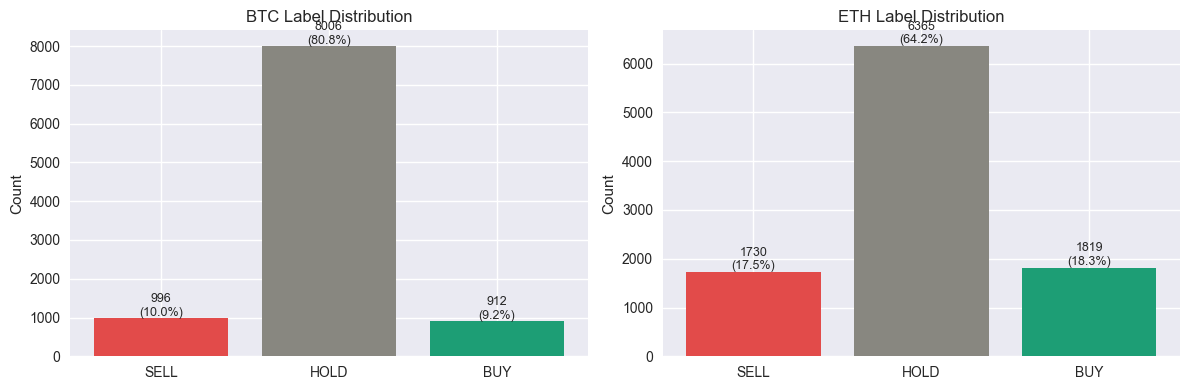

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
colors = ['#E24B4A', '#888780', '#1D9E75']

for ax, (df, symbol) in zip(axes, [(btc_labeled, 'BTC'), (eth_labeled, 'ETH')]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar([label_map[i] for i in counts.index], counts.values, color=colors)
    ax.set_title(f'{symbol} Label Distribution')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/diagrams/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [10]:
from sklearn.utils import resample

# Step 1: Sort by timestamp first (critical!)
btc_labeled = btc_labeled.sort_values('timestamp').reset_index(drop=True)
eth_labeled = eth_labeled.sort_values('timestamp').reset_index(drop=True)

# Step 2: Temporal split BEFORE balancing (80% train, 20% test)
btc_split = int(len(btc_labeled) * 0.8)
eth_split = int(len(eth_labeled) * 0.8)

btc_train_raw = btc_labeled.iloc[:btc_split].copy()
btc_test_raw  = btc_labeled.iloc[btc_split:].copy()

eth_train_raw = eth_labeled.iloc[:eth_split].copy()
eth_test_raw  = eth_labeled.iloc[eth_split:].copy()

print(f"BTC train: {btc_train_raw.shape} | {btc_train_raw['timestamp'].iloc[0]} → {btc_train_raw['timestamp'].iloc[-1]}")
print(f"BTC test:  {btc_test_raw.shape}  | {btc_test_raw['timestamp'].iloc[0]} → {btc_test_raw['timestamp'].iloc[-1]}")
print(f"\nETH train: {eth_train_raw.shape} | {eth_train_raw['timestamp'].iloc[0]} → {eth_train_raw['timestamp'].iloc[-1]}")
print(f"ETH test:  {eth_test_raw.shape}  | {eth_test_raw['timestamp'].iloc[0]} → {eth_test_raw['timestamp'].iloc[-1]}")

BTC train: (7931, 36) | 2025-02-04 11:00:00 → 2025-12-31 21:00:00
BTC test:  (1983, 36)  | 2025-12-31 22:00:00 → 2026-03-24 12:00:00

ETH train: (7931, 36) | 2025-02-04 11:00:00 → 2025-12-31 21:00:00
ETH test:  (1983, 36)  | 2025-12-31 22:00:00 → 2026-03-24 12:00:00


In [11]:
def balance_classes(df, symbol):
    sell = df[df['label'] == 0]
    hold = df[df['label'] == 1]
    buy  = df[df['label'] == 2]

    print(f"{symbol} before balancing: SELL={len(sell)}, HOLD={len(hold)}, BUY={len(buy)}")

    minority_size = max(len(sell), len(buy))
    target_hold = minority_size * 2

    hold_downsampled = resample(hold,
                                replace=False,
                                n_samples=target_hold,
                                random_state=42)

    df_balanced = pd.concat([sell, hold_downsampled, buy])
    df_balanced = df_balanced.sort_values('timestamp').reset_index(drop=True)

    counts = df_balanced['label'].value_counts().sort_index()
    label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
    print(f"{symbol} after balancing:")
    for k, v in counts.items():
        print(f"  {label_map[k]}: {v} ({v/len(df_balanced)*100:.1f}%)")
    print()
    return df_balanced

# Balance ONLY train set
btc_train = balance_classes(btc_train_raw.copy(), 'BTC train')
eth_train = balance_classes(eth_train_raw.copy(), 'ETH train')

# Keep test set as-is (real world distribution)
btc_test = btc_test_raw.copy()
eth_test = eth_test_raw.copy()

print(f"BTC test set (no balancing): {btc_test.shape}")
print(f"  Label distribution: {btc_test['label'].value_counts().to_dict()}")
print(f"\nETH test set (no balancing): {eth_test.shape}")
print(f"  Label distribution: {eth_test['label'].value_counts().to_dict()}")

BTC train before balancing: SELL=733, HOLD=6535, BUY=663
BTC train after balancing:
  SELL: 733 (25.6%)
  HOLD: 1466 (51.2%)
  BUY: 663 (23.2%)

ETH train before balancing: SELL=1350, HOLD=5082, BUY=1499
ETH train after balancing:
  SELL: 1350 (23.1%)
  HOLD: 2998 (51.3%)
  BUY: 1499 (25.6%)

BTC test set (no balancing): (1983, 36)
  Label distribution: {1: 1471, 0: 263, 2: 249}

ETH test set (no balancing): (1983, 36)
  Label distribution: {1: 1283, 0: 380, 2: 320}


In [12]:
# Save train and test sets separately
btc_train.to_csv('../data/processed/BTC_USDT_train.csv', index=False)
btc_test.to_csv('../data/processed/BTC_USDT_test.csv', index=False)
eth_train.to_csv('../data/processed/ETH_USDT_train.csv', index=False)
eth_test.to_csv('../data/processed/ETH_USDT_test.csv', index=False)

print("Saved all datasets!")
print(f"BTC train: {btc_train.shape} → data/processed/BTC_USDT_train.csv")
print(f"BTC test:  {btc_test.shape}  → data/processed/BTC_USDT_test.csv")
print(f"ETH train: {eth_train.shape} → data/processed/ETH_USDT_train.csv")
print(f"ETH test:  {eth_test.shape}  → data/processed/ETH_USDT_test.csv")

Saved all datasets!
BTC train: (2862, 36) → data/processed/BTC_USDT_train.csv
BTC test:  (1983, 36)  → data/processed/BTC_USDT_test.csv
ETH train: (5847, 36) → data/processed/ETH_USDT_train.csv
ETH test:  (1983, 36)  → data/processed/ETH_USDT_test.csv
